In [48]:
import pandas as pd

df = pd.read_csv("/content/transfer_dataset.csv")

print(df.shape)
print(df.head())
print(df["is_loaned"].value_counts())


(1014, 8)
   age        position  minutes_played  goals  assists  market_value  \
0   38  Centre-Forward            1192      8        0     6000000.0   
1   42      Goalkeeper             360      0        0      150000.0   
2   39  Centre-Forward             236      0        0     1500000.0   
3   27  Centre-Forward              67      0        1      400000.0   
4   28  Centre-Forward              68      0        1      350000.0   

   previous_transfers  is_loaned  
0                   2          0  
1                   5          0  
2                   9          0  
3                   3          0  
4                   4          1  
is_loaned
0    636
1    378
Name: count, dtype: int64


In [49]:
import numpy as np
import pandas as pd

print("Dataset shape:", df.shape)
print("Duplicate rows:", df.duplicated().sum())

# Count -1 markers in each column
missing = (df == -1).sum().sort_values(ascending=False)
print("\nColumns containing -1:")
print(missing[missing > 0])

print("\nActual NaN values:", df.isna().sum().sum())
print("\nTarget distribution:")
print(df["is_loaned"].value_counts())


Dataset shape: (1014, 8)
Duplicate rows: 0

Columns containing -1:
Series([], dtype: int64)

Actual NaN values: 0

Target distribution:
is_loaned
0    636
1    378
Name: count, dtype: int64


In [50]:
!pip install -q xgboost

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    cross_val_predict,
    RandomizedSearchCV,
    StratifiedKFold,
    RepeatedStratifiedKFold,
)
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

sns.set_theme(style="whitegrid")
print("Libraries imported successfully!")

Libraries imported successfully!


In [52]:
print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDescriptive statistics:")
display(df.describe(include="all").T)

Dataset shape: (1014, 8)

Column names:
['age', 'position', 'minutes_played', 'goals', 'assists', 'market_value', 'previous_transfers', 'is_loaned']

Data types:
age                     int64
position               object
minutes_played          int64
goals                   int64
assists                 int64
market_value          float64
previous_transfers      int64
is_loaned               int64
dtype: object

Missing values:
age                   0
position              0
minutes_played        0
goals                 0
assists               0
market_value          0
previous_transfers    0
is_loaned             0
dtype: int64

Descriptive statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,1014.0,NaN,NaN,NaN,24.993097,4.179694,17.0,22.0,25.0,28.0,42.0
position,1014,13,Centre-Forward,222,NaN,NaN,NaN,NaN,NaN,NaN,NaN
minutes_played,1014.0,NaN,NaN,NaN,655.097633,720.810534,1.0,91.0,355.5,1016.75,3290.0
goals,1014.0,NaN,NaN,NaN,1.176529,2.386909,0.0,0.0,0.0,1.0,22.0
assists,1014.0,NaN,NaN,NaN,0.7643,1.477928,0.0,0.0,0.0,1.0,12.0
market_value,1014.0,NaN,NaN,NaN,5293762.327416,8647384.392572,25000.0,700000.0,2000000.0,6000000.0,70000000.0
previous_transfers,1014.0,NaN,NaN,NaN,3.871795,2.666255,0.0,2.0,3.0,5.0,16.0
is_loaned,1014.0,NaN,NaN,NaN,0.372781,0.483783,0.0,0.0,0.0,1.0,1.0


is_loaned
0    636
1    378
Name: count, dtype: int64


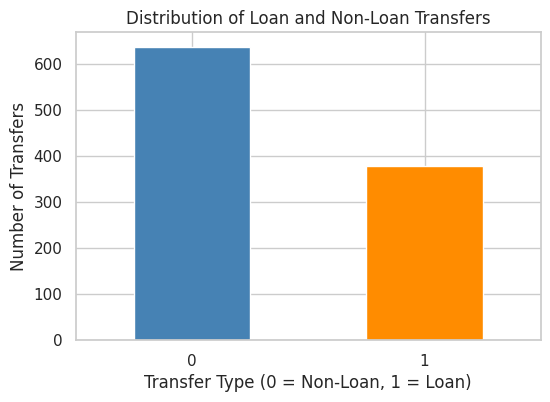

In [53]:
target = "is_loaned"

print(df[target].value_counts())

df[target].value_counts().sort_index().plot(
    kind="bar",
    figsize=(6, 4),
    color=["steelblue", "darkorange"]
)

plt.title("Distribution of Loan and Non-Loan Transfers")
plt.xlabel("Transfer Type (0 = Non-Loan, 1 = Loan)")
plt.ylabel("Number of Transfers")
plt.xticks(rotation=0)
plt.show()

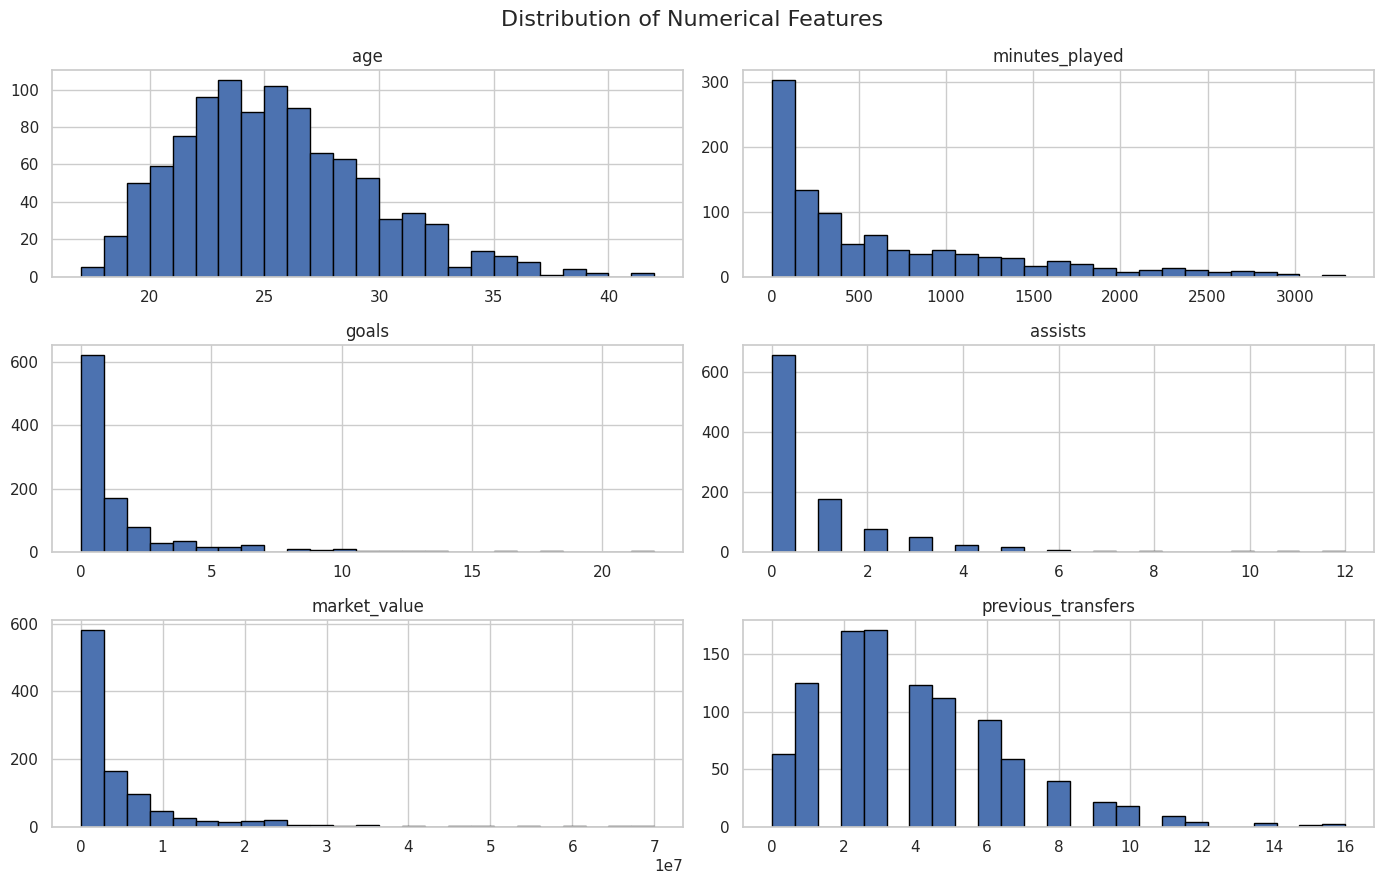

In [54]:
numeric_cols = [
    "age",
    "minutes_played",
    "goals",
    "assists",
    "market_value",
    "previous_transfers"
]

df[numeric_cols].hist(
    figsize=(14, 9),
    bins=25,
    edgecolor="black"
)

plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

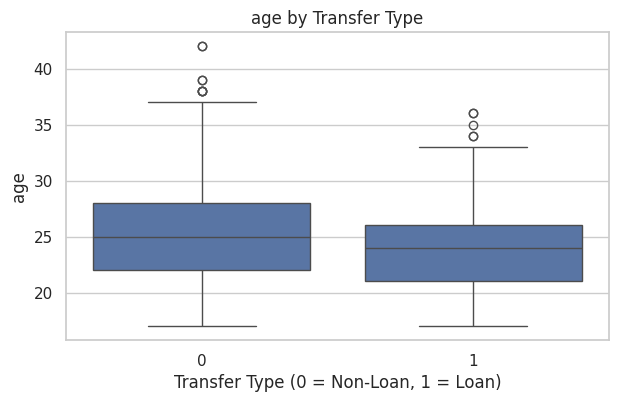

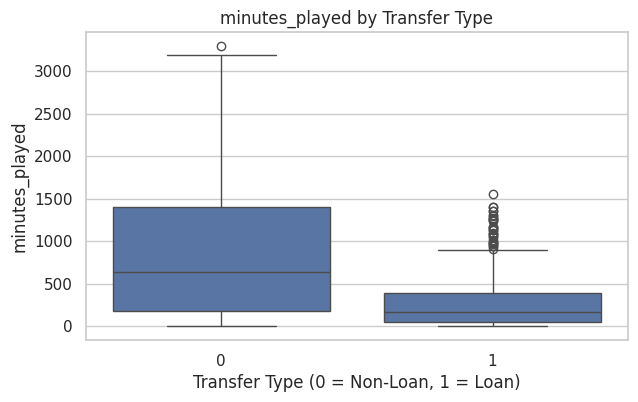

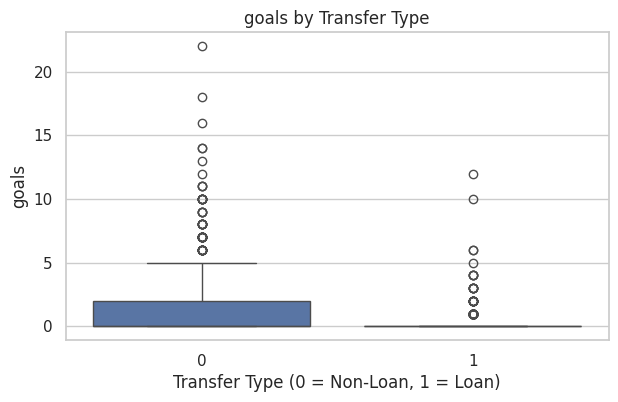

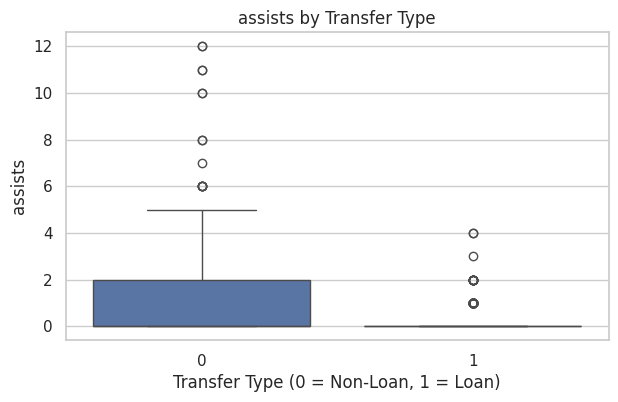

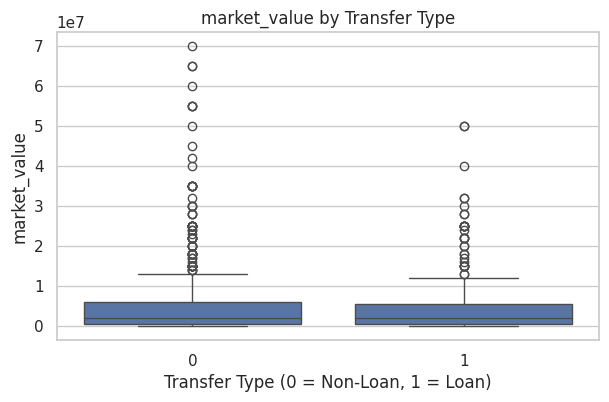

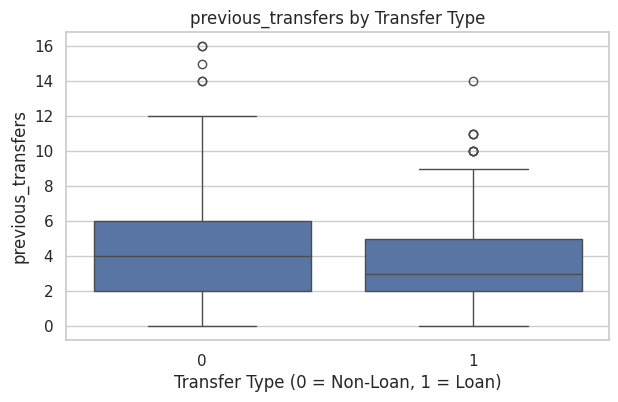

In [55]:
for col in numeric_cols:
    plt.figure(figsize=(7, 4))

    sns.boxplot(
        data=df,
        x="is_loaned",
        y=col
    )

    plt.title(f"{col} by Transfer Type")
    plt.xlabel("Transfer Type (0 = Non-Loan, 1 = Loan)")
    plt.show()

In [56]:
# ------------------------------------------------------------------
# Data
# ------------------------------------------------------------------
X = df.drop(columns=["is_loaned"])
y = df["is_loaned"].astype(int)

categorical_features = ["position"]
numerical_features = [
    "age", "minutes_played", "goals", "assists",
    "market_value", "previous_transfers",
]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y,
)

# ------------------------------------------------------------------
# Leak-free preprocessor with rare-category grouping
# ------------------------------------------------------------------
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="infrequent_if_exist",
        min_frequency=10,
        sparse_output=False,
    )),
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numerical_features),
    ("cat", categorical_transformer, categorical_features),
])

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))
print("Positive rate (train):", round(y_train.mean(), 3))
print("Positive rate (test) :", round(y_test.mean(), 3))

Training samples: 811
Testing samples : 203
Positive rate (train): 0.372
Positive rate (test) : 0.374


In [57]:
# ------------------------------------------------------------------
# Base estimators
# n_jobs=1 inside RF / XGB to avoid oversubscription when the outer
# search uses n_jobs=-1.
# ------------------------------------------------------------------
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000, class_weight="balanced",
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=5, min_samples_leaf=20,
        class_weight="balanced", random_state=42,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, min_samples_leaf=5,
        class_weight="balanced", random_state=42, n_jobs=1,
    ),
    "KNN": KNeighborsClassifier(n_neighbors=21),
    "XGBoost": XGBClassifier(
        n_estimators=200, max_depth=3, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        objective="binary:logistic", eval_metric="logloss",
        random_state=42, n_jobs=1,
    ),
}

# ------------------------------------------------------------------
# Baseline CV AUC (same CV scheme as the search will use)
# ------------------------------------------------------------------
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=42)

baseline_rows = []
for name, base_model in models.items():
    pipe = Pipeline([
        ("preprocessor", clone(preprocessor)),
        ("classifier",   clone(base_model)),
    ])
    cv_auc = cross_val_score(
        pipe, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1,
    )
    pipe.fit(X_train, y_train)
    prob = pipe.predict_proba(X_test)[:, 1]

    baseline_rows.append({
        "Model":        name,
        "CV AUC mean":  cv_auc.mean(),
        "CV AUC std":   cv_auc.std(),
        "Test ROC-AUC": roc_auc_score(y_test, prob),
        "Test PR-AUC":  average_precision_score(y_test, prob),
        "Test F1@0.5":  f1_score(y_test, (prob >= 0.5).astype(int),
                                 zero_division=0),
    })

baseline_df = (
    pd.DataFrame(baseline_rows)
      .set_index("Model")
      .sort_values("CV AUC mean", ascending=False)
)
display(baseline_df.round(3))

,CV AUC mean,CV AUC std,Test ROC-AUC,Test PR-AUC,Test F1@0.5
Model,,,,,
Logistic Regression,0.738,0.028,0.741,0.571,0.604
Random Forest,0.736,0.031,0.749,0.548,0.619
XGBoost,0.725,0.032,0.743,0.540,0.585
KNN,0.720,0.024,0.707,0.525,0.526
Decision Tree,0.720,0.035,0.704,0.492,0.624


In [58]:
# ------------------------------------------------------------------
# Regularized grids tuned for a small dataset (~7 features)
# ------------------------------------------------------------------
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos = neg / pos
print(f"scale_pos_weight = {scale_pos:.2f}")

param_grids = {
    "Logistic Regression": {
        "classifier__C":            [0.003, 0.01, 0.03, 0.1, 0.3, 1, 3, 10],
        "classifier__penalty":      ["l1", "l2"],
        "classifier__solver":       ["liblinear"],
        "classifier__class_weight": [None, "balanced"],
    },
    "Decision Tree": {
        "classifier__max_depth":         [2, 3, 4, 5],
        "classifier__min_samples_leaf":  [10, 20, 30, 40, 60],
        "classifier__min_samples_split": [2, 5, 10, 20],
        "classifier__class_weight":      [None, "balanced"],
    },
    "Random Forest": {
        "classifier__n_estimators":     [100, 200, 300],
        "classifier__max_depth":        [3, 5, 8, None],
        "classifier__min_samples_leaf": [5, 10, 15, 20],
        "classifier__max_features":     ["sqrt", 0.5],
        "classifier__class_weight":     [None, "balanced"],
    },
    "KNN": {
        "classifier__n_neighbors": [15, 21, 31, 41, 51, 61],
        "classifier__weights":     ["uniform", "distance"],
        "classifier__p":           [1, 2],
    },
    "XGBoost": {
        "classifier__n_estimators":     [100, 200, 300],
        "classifier__max_depth":        [2, 3],
        "classifier__learning_rate":    [0.01, 0.03, 0.05],
        "classifier__min_child_weight": [5, 10, 15, 20],
        "classifier__reg_lambda":       [5, 10, 15, 20],
        "classifier__subsample":        [0.7, 0.9],
        "classifier__colsample_bytree": [0.7, 0.9],
        "classifier__scale_pos_weight": [1, scale_pos],
    },
}

tuned_models      = {}
best_params_store = {}
cv_auc_scores     = {}

for name, base_model in models.items():
    print(f"\n=== Tuning {name} ===")

    pipeline = Pipeline([
        ("preprocessor", clone(preprocessor)),
        ("classifier",   clone(base_model)),
    ])

    search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_grids[name],
        n_iter=15,
        scoring="roc_auc",
        cv=cv,
        random_state=42,
        n_jobs=-1,
        refit=True,
        verbose=0,
    )

    search.fit(X_train, y_train)

    tuned_models[name]      = search.best_estimator_
    best_params_store[name] = search.best_params_

    idx = search.best_index_
    fold_scores = np.array([
        search.cv_results_[f"split{k}_test_score"][idx]
        for k in range(cv.get_n_splits())
    ])
    cv_auc_scores[name] = fold_scores

    # NOTE: best_score_ is the max over 15 draws → optimistic.
    #       The honest number is Test ROC-AUC in the final table.
    print(f"Best CV ROC-AUC (optimistic): {search.best_score_:.4f} "
          f"(fold std {fold_scores.std():.4f})")
    print(f"Best params: {search.best_params_}")

scale_pos_weight = 1.69

=== Tuning Logistic Regression ===
Best CV ROC-AUC (optimistic): 0.7424 (fold std 0.0287)
Best params: {'classifier__solver': 'liblinear', 'classifier__penalty': 'l2', 'classifier__class_weight': 'balanced', 'classifier__C': 0.03}

=== Tuning Decision Tree ===
Best CV ROC-AUC (optimistic): 0.7379 (fold std 0.0342)
Best params: {'classifier__min_samples_split': 5, 'classifier__min_samples_leaf': 20, 'classifier__max_depth': 3, 'classifier__class_weight': 'balanced'}

=== Tuning Random Forest ===
Best CV ROC-AUC (optimistic): 0.7473 (fold std 0.0275)
Best params: {'classifier__n_estimators': 100, 'classifier__min_samples_leaf': 20, 'classifier__max_features': 0.5, 'classifier__max_depth': 5, 'classifier__class_weight': None}

=== Tuning KNN ===
Best CV ROC-AUC (optimistic): 0.7361 (fold std 0.0338)
Best params: {'classifier__weights': 'distance', 'classifier__p': 1, 'classifier__n_neighbors': 41}

=== Tuning XGBoost ===
Best CV ROC-AUC (optimistic): 0.7442 (fold 

In [59]:
# ------------------------------------------------------------------
# Metric helper.
# Threshold-independent: ROC-AUC, PR-AUC, Gini, KS (no suffix).
# Threshold-dependent:   Accuracy, Precision, Recall, F1 (@<thr>).
# ------------------------------------------------------------------
def ks_statistic(y_true, y_prob):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    return float(np.max(tpr - fpr))

def evaluate(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)
    auc    = roc_auc_score(y_true, y_prob)
    return {
        "ROC-AUC": auc,
        "PR-AUC":  average_precision_score(y_true, y_prob),
        "Gini":    2 * auc - 1,
        "KS":      ks_statistic(y_true, y_prob),
        f"Accuracy@{threshold:.2f}":  accuracy_score(y_true, y_pred),
        f"Precision@{threshold:.2f}": precision_score(y_true, y_pred, zero_division=0),
        f"Recall@{threshold:.2f}":    recall_score(y_true, y_pred, zero_division=0),
        f"F1@{threshold:.2f}":        f1_score(y_true, y_pred, zero_division=0),
    }

# ------------------------------------------------------------------
# Threshold grid 0.20–0.70 to avoid degenerate low-threshold picks.
# ------------------------------------------------------------------
def best_f1_threshold(y_true, y_prob, lo=0.20, hi=0.70, step=0.01):
    thresholds = np.arange(lo, hi + 1e-9, step)
    scores = [
        f1_score(y_true, (y_prob >= t).astype(int), zero_division=0)
        for t in thresholds
    ]
    return float(thresholds[int(np.argmax(scores))])

tuned_results = []

for name, model in tuned_models.items():
    # Out-of-fold probabilities on the TRAIN set only
    oof_prob = cross_val_predict(
        clone(model), X_train, y_train,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        method="predict_proba", n_jobs=-1,
    )[:, 1]
    thr = best_f1_threshold(y_train, oof_prob)

    test_prob = model.predict_proba(X_test)[:, 1]

    row = {"Model": name, "OOF-F1 Threshold": round(thr, 2)}
    row.update(evaluate(y_test, test_prob, threshold=0.50))
    row.update(evaluate(y_test, test_prob, threshold=thr))

    fold = cv_auc_scores[name]
    row["CV AUC mean"] = fold.mean()
    row["CV AUC std"]  = fold.std()
    row["Best Parameters"] = best_params_store[name]

    tuned_results.append(row)

# Sort by CV AUC mean (test AUC is a sanity check, not the ranking key)
tuned_results_df = (
    pd.DataFrame(tuned_results)
      .sort_values("CV AUC mean", ascending=False)
      .reset_index(drop=True)
)

top_mean = tuned_results_df["CV AUC mean"].iloc[0]
top_std  = tuned_results_df["CV AUC std"].iloc[0]
tuned_results_df["Tied with best (1σ)"] = (
    tuned_results_df["CV AUC mean"] >= top_mean - top_std
)

base_cols = [
    "Model",
    "CV AUC mean", "CV AUC std", "Tied with best (1σ)",
    "ROC-AUC", "PR-AUC", "Gini", "KS",
]
thr_cols = [c for c in tuned_results_df.columns
            if c.startswith(("Accuracy@", "Precision@", "Recall@", "F1@"))]
display_cols = base_cols + ["OOF-F1 Threshold"] + sorted(thr_cols)

display(tuned_results_df[display_cols].round(3))

,Model,CV AUC mean,CV AUC std,Tied with best (1σ),ROC-AUC,PR-AUC,Gini,KS,OOF-F1 Threshold,Accuracy@0.27,...,Precision@0.44,Precision@0.45,Precision@0.47,Precision@0.50,Recall@0.27,Recall@0.36,Recall@0.44,Recall@0.45,Recall@0.47,Recall@0.50
0,Random Forest,0.747,0.027,True,0.750,0.550,0.501,0.425,0.27,0.626,...,NaN,NaN,NaN,0.562,0.921,NaN,NaN,NaN,NaN,0.539
1,XGBoost,0.744,0.026,True,0.741,0.544,0.483,0.399,0.44,NaN,...,0.508,NaN,NaN,0.530,NaN,NaN,0.829,NaN,NaN,0.697
2,Logistic Regression,0.742,0.029,True,0.756,0.599,0.511,0.409,0.47,NaN,...,NaN,NaN,0.513,0.532,NaN,NaN,NaN,NaN,0.803,0.776
3,Decision Tree,0.738,0.034,True,0.726,0.531,0.453,0.388,0.45,NaN,...,NaN,0.52,NaN,0.520,NaN,NaN,NaN,0.868,NaN,0.868
4,KNN,0.736,0.034,True,0.696,0.518,0.391,0.372,0.36,NaN,...,NaN,NaN,NaN,0.500,NaN,0.921,NaN,NaN,NaN,0.553


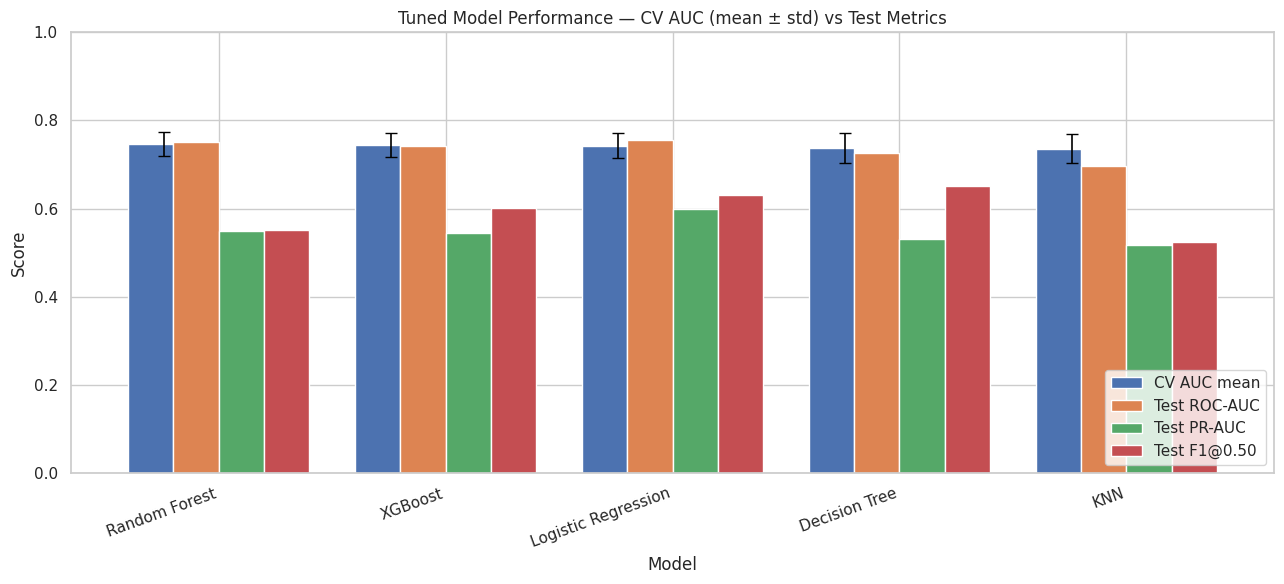

In [61]:
# ------------------------------------------------------------------
# Bar chart: CV AUC mean ± std  vs  Test ROC-AUC / PR-AUC / F1
# Sorted by CV AUC mean (the ranking key).
# ------------------------------------------------------------------
plot_df = (
    tuned_results_df
      .set_index("Model")[
          ["CV AUC mean", "ROC-AUC", "PR-AUC", "F1@0.50"]
      ]
      .rename(columns={
          "ROC-AUC":  "Test ROC-AUC",
          "PR-AUC":   "Test PR-AUC",
          "F1@0.50":  "Test F1@0.50",
      })
      .sort_values("CV AUC mean", ascending=False)
)

# 1) Plain bar chart — no yerr here
ax = plot_df.plot(kind="bar", figsize=(13, 6), width=0.8)

# 2) Add CV AUC std as error bars on the first column only
x = np.arange(len(plot_df))
cv_std = tuned_results_df.set_index("Model").loc[plot_df.index, "CV AUC std"].values

ax.errorbar(
    x - 0.24,               # center of the first bar in each group
    plot_df["CV AUC mean"].values,
    yerr=cv_std,            # shape (5,) — matches the 5 bars
    fmt="none",
    ecolor="black",
    capsize=4,
    linewidth=1.2,
)

ax.set_title("Tuned Model Performance — CV AUC (mean ± std) vs Test Metrics")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.set_xticklabels(plot_df.index, rotation=20, ha="right")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

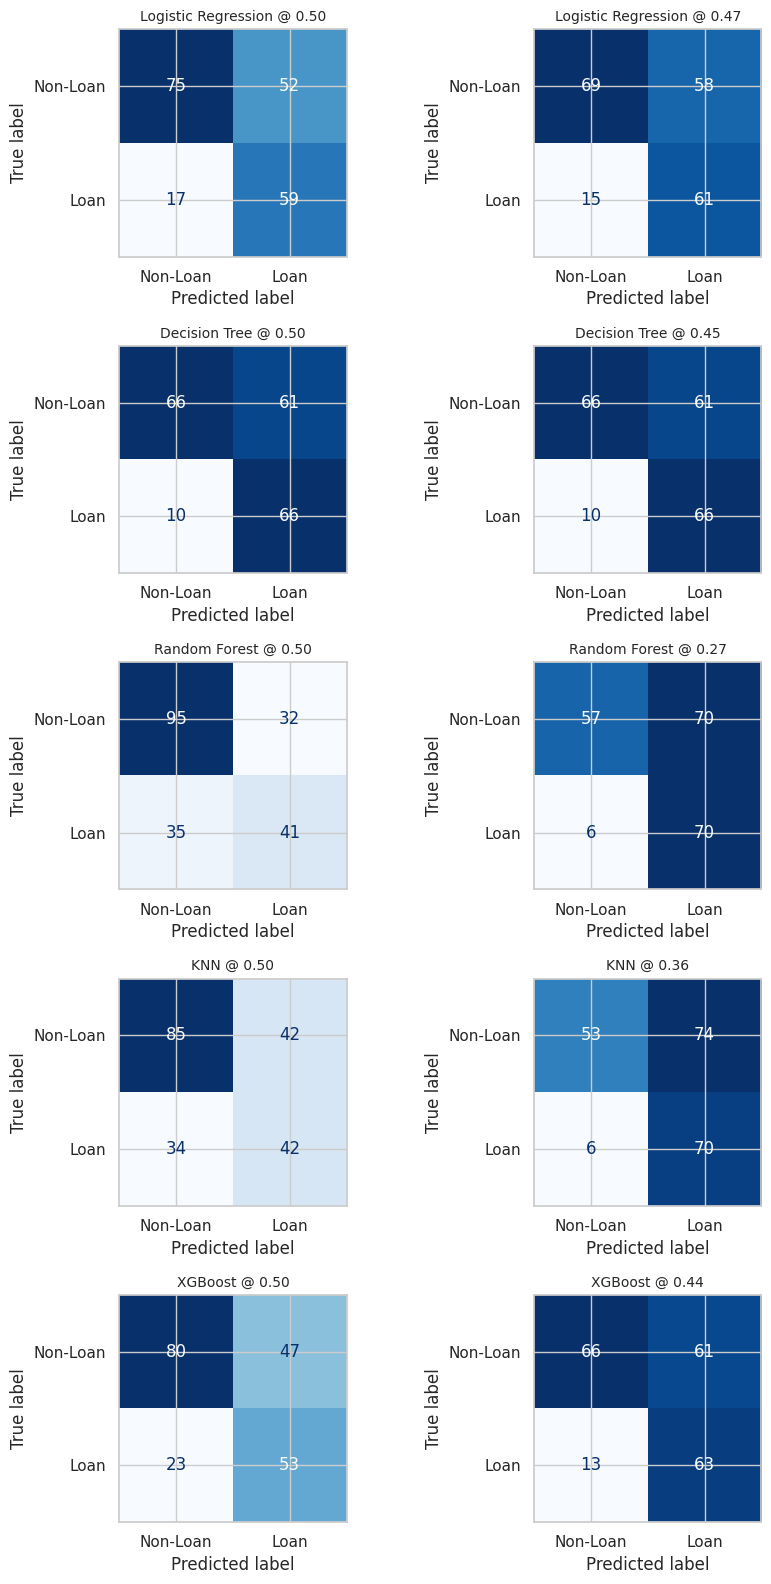

In [62]:
# ------------------------------------------------------------------
# Two rows per model:
#   left  column → decision threshold = 0.50
#   right column → OOF-selected threshold
# ------------------------------------------------------------------
n_models = len(tuned_models)
fig, axes = plt.subplots(n_models, 2, figsize=(9, 3.2 * n_models))
if n_models == 1:
    axes = np.array([axes])

for row_idx, (name, model) in enumerate(tuned_models.items()):
    test_prob = model.predict_proba(X_test)[:, 1]
    thr = float(
        tuned_results_df.loc[
            tuned_results_df["Model"] == name, "OOF-F1 Threshold"
        ].iloc[0]
    )

    for col_idx, t in enumerate([0.50, thr]):
        y_pred = (test_prob >= t).astype(int)
        ConfusionMatrixDisplay.from_predictions(
            y_test, y_pred,
            display_labels=["Non-Loan", "Loan"],
            cmap="Blues",
            ax=axes[row_idx, col_idx],
            colorbar=False,
        )
        axes[row_idx, col_idx].set_title(
            f"{name} @ {t:.2f}", fontsize=10,
        )

plt.tight_layout()
plt.show()

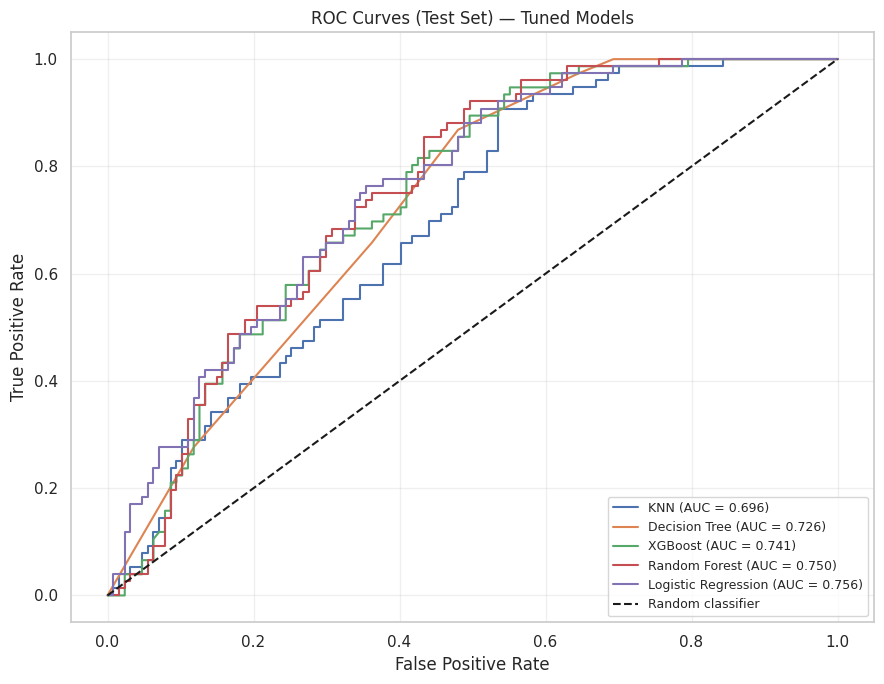

In [63]:
# ------------------------------------------------------------------
# ROC curves on the TEST set, sorted by test AUC in the legend.
# ------------------------------------------------------------------
plt.figure(figsize=(9, 7))

roc_entries = []
for name, model in tuned_models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    roc_entries.append((auc, name, fpr, tpr))

# Plot in ascending AUC so the best curve ends on top of the legend
for auc, name, fpr, tpr in sorted(roc_entries):
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (Test Set) — Tuned Models")
plt.legend(loc="lower right", fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [65]:
# ------------------------------------------------------------------
# Classification reports on the TEST set, at both 0.50 and the
# OOF-selected threshold. Sorted by CV AUC mean.
# ------------------------------------------------------------------
for name in tuned_results_df["Model"]:
    model = tuned_models[name]
    test_prob = model.predict_proba(X_test)[:, 1]
    thr = float(
        tuned_results_df.loc[
            tuned_results_df["Model"] == name, "OOF-F1 Threshold"
        ].iloc[0]
    )

    print(f"\n{'=' * 55}")
    print(f"{name}   (OOF threshold = {thr:.2f})")
    print("=" * 55)

    for t in [0.50, thr]:
        print(f"\n--- threshold = {t:.2f} ---")
        print(classification_report(
            y_test,
            (test_prob >= t).astype(int),
            target_names=["Non-Loan", "Loan"],
            digits=3,
            zero_division=0,
        ))


Random Forest   (OOF threshold = 0.27)

--- threshold = 0.50 ---
              precision    recall  f1-score   support

    Non-Loan      0.731     0.748     0.739       127
        Loan      0.562     0.539     0.550        76

    accuracy                          0.670       203
   macro avg      0.646     0.644     0.645       203
weighted avg      0.667     0.670     0.669       203


--- threshold = 0.27 ---
              precision    recall  f1-score   support

    Non-Loan      0.905     0.449     0.600       127
        Loan      0.500     0.921     0.648        76

    accuracy                          0.626       203
   macro avg      0.702     0.685     0.624       203
weighted avg      0.753     0.626     0.618       203


XGBoost   (OOF threshold = 0.44)

--- threshold = 0.50 ---
              precision    recall  f1-score   support

    Non-Loan      0.777     0.630     0.696       127
        Loan      0.530     0.697     0.602        76

    accuracy                  

In [66]:
!pip install -q streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 51.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 49.2 MB/s eta 0:00:00


In [67]:
df.to_csv("df.csv", index=False)
print("Saved df.csv:", df.shape)

Saved df.csv: (1014, 8)


In [68]:
%%writefile app.py
"""Streamlit dashboard — football player loan prediction."""

import numpy as np
import pandas as pd
import streamlit as st
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, cross_val_score, cross_val_predict,
    StratifiedKFold, RepeatedStratifiedKFold,
)
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve,
    precision_recall_curve, f1_score, precision_score,
    recall_score, accuracy_score, confusion_matrix,
    ConfusionMatrixDisplay,
)

sns.set_theme(style="whitegrid")

st.set_page_config(
    page_title="Loan Prediction Dashboard",
    page_icon="⚽", layout="wide",
)

# ==================================================================
# Cached data + training
# ==================================================================
@st.cache_data(show_spinner="Loading data…")
def load_data():
    return pd.read_csv("df.csv")


@st.cache_resource(show_spinner="Training models… (first run only)")
def train_models(df):
    X = df.drop(columns=["is_loaned"])
    y = df["is_loaned"].astype(int)

    categorical_features = ["position"]
    numerical_features = [
        "age", "minutes_played", "goals", "assists",
        "market_value", "previous_transfers",
    ]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20, random_state=42, stratify=y,
    )

    numeric_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
    ])
    categorical_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(
            handle_unknown="infrequent_if_exist",
            min_frequency=10, sparse_output=False,
        )),
    ])
    preprocessor = ColumnTransformer([
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features),
    ])

    models = {
        "Logistic Regression": LogisticRegression(
            C=0.03, penalty="l2", solver="liblinear",
            class_weight="balanced", max_iter=2000,
        ),
        "Decision Tree": DecisionTreeClassifier(
            max_depth=3, min_samples_leaf=20, min_samples_split=5,
            class_weight="balanced", random_state=42,
        ),
        "Random Forest": RandomForestClassifier(
            n_estimators=100, max_depth=5, min_samples_leaf=20,
            max_features=0.5, class_weight=None,
            random_state=42, n_jobs=1,
        ),
        "KNN": KNeighborsClassifier(
            n_neighbors=41, weights="distance", p=1,
        ),
        "XGBoost": XGBClassifier(
            n_estimators=200, max_depth=3, learning_rate=0.01,
            subsample=0.9, colsample_bytree=0.9,
            min_child_weight=20, reg_lambda=15,
            scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
            objective="binary:logistic", eval_metric="logloss",
            random_state=42, n_jobs=1,
        ),
    }

    cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=42)

    trained, rows = {}, []
    for name, model in models.items():
        pipe = Pipeline([
            ("preprocessor", clone(preprocessor)),
            ("classifier",   clone(model)),
        ])
        cv_scores = cross_val_score(
            pipe, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1,
        )
        pipe.fit(X_train, y_train)

        test_prob    = pipe.predict_proba(X_test)[:, 1]
        test_pred_50 = (test_prob >= 0.5).astype(int)

        oof_prob = cross_val_predict(
            clone(pipe), X_train, y_train,
            cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
            method="predict_proba", n_jobs=-1,
        )[:, 1]
        thresholds = np.arange(0.20, 0.71, 0.01)
        f1s = [f1_score(y_train, (oof_prob >= t).astype(int),
                        zero_division=0) for t in thresholds]
        thr = float(thresholds[int(np.argmax(f1s))])
        test_pred_thr = (test_prob >= thr).astype(int)

        rows.append({
            "Model":         name,
            "CV AUC mean":   cv_scores.mean(),
            "CV AUC std":    cv_scores.std(),
            "Test ROC-AUC":  roc_auc_score(y_test, test_prob),
            "Test PR-AUC":   average_precision_score(y_test, test_prob),
            "F1@0.50":       f1_score(y_test, test_pred_50, zero_division=0),
            "OOF Threshold": thr,
            "F1@thr":        f1_score(y_test, test_pred_thr, zero_division=0),
            "Precision@thr": precision_score(y_test, test_pred_thr, zero_division=0),
            "Recall@thr":    recall_score(y_test, test_pred_thr, zero_division=0),
            "Accuracy@thr":  accuracy_score(y_test, test_pred_thr),
        })
        trained[name] = pipe

    results = (
        pd.DataFrame(rows)
          .sort_values("CV AUC mean", ascending=False)
          .reset_index(drop=True)
    )
    return trained, results, X_train, X_test, y_train, y_test


# ==================================================================
# Sidebar
# ==================================================================
st.sidebar.title("⚽ Loan Prediction Dashboard")
st.sidebar.markdown("Football player loan prediction — model comparison & live scoring.")

df = load_data()
st.sidebar.caption(f"**{len(df):,}** rows · **{df.shape[1]}** columns")
st.sidebar.caption(f"Positive rate: **{df['is_loaned'].mean():.1%}**")

trained, results, X_train, X_test, y_train, y_test = train_models(df)

# ==================================================================
# Header
# ==================================================================
st.title("⚽ Football Player Loan Prediction")
st.markdown(
    "Model comparison on repeated 5×2 stratified CV ROC-AUC. "
    "All five models are statistically tied within one standard deviation — "
    "**Logistic Regression** is preferred for test-set ROC-AUC and PR-AUC."
)

tab_overview, tab_curves, tab_cm, tab_predict, tab_data = st.tabs([
    "📊 Model Comparison", "📈 ROC & PR Curves",
    "🔢 Confusion Matrices", "🎯 Live Prediction", "📁 Data",
])

# ------------------------------------------------------------------
# Tab 1
# ------------------------------------------------------------------
with tab_overview:
    st.subheader("Metrics table (sorted by CV AUC mean)")

    styled = (
        results.set_index("Model").style
        .background_gradient(cmap="Greens",
            subset=["CV AUC mean", "Test ROC-AUC", "Test PR-AUC"])
        .format({
            "CV AUC mean": "{:.3f}", "CV AUC std": "{:.3f}",
            "Test ROC-AUC": "{:.3f}", "Test PR-AUC": "{:.3f}",
            "F1@0.50": "{:.3f}", "OOF Threshold": "{:.2f}",
            "F1@thr": "{:.3f}", "Precision@thr": "{:.3f}",
            "Recall@thr": "{:.3f}", "Accuracy@thr": "{:.3f}",
        })
    )
    st.dataframe(styled, use_container_width=True)

    st.markdown("---")
    st.subheader("CV AUC mean ± std  vs  test metrics")

    plot_df = results.set_index("Model")[
        ["CV AUC mean", "Test ROC-AUC", "Test PR-AUC", "F1@0.50"]
    ].rename(columns={"Test ROC-AUC": "Test ROC-AUC",
                      "Test PR-AUC": "Test PR-AUC",
                      "F1@0.50": "F1@0.50"})

    fig, ax = plt.subplots(figsize=(11, 4.5))
    plot_df.plot(kind="bar", ax=ax, width=0.8)
    x = np.arange(len(plot_df))
    ax.errorbar(
        x - 0.24,
        plot_df["CV AUC mean"].values,
        yerr=results.set_index("Model").loc[plot_df.index, "CV AUC std"].values,
        fmt="none", ecolor="black", capsize=4, linewidth=1.2,
    )
    ax.set_ylim(0, 1)
    ax.set_ylabel("Score")
    ax.set_xticklabels(plot_df.index, rotation=15, ha="right")
    ax.legend(loc="lower right")
    ax.set_title("Tuned Model Performance")
    plt.tight_layout()
    st.pyplot(fig)

    st.info(
        "All five models sit within one standard deviation of the top — "
        "treat them as statistically tied. Logistic Regression is the "
        "recommended pick based on test ROC-AUC and PR-AUC."
    )

# ------------------------------------------------------------------
# Tab 2
# ------------------------------------------------------------------
with tab_curves:
    col1, col2 = st.columns(2)

    with col1:
        st.subheader("ROC curves (test set)")
        fig, ax = plt.subplots(figsize=(6, 5.5))
        entries = []
        for name, pipe in trained.items():
            prob = pipe.predict_proba(X_test)[:, 1]
            fpr, tpr, _ = roc_curve(y_test, prob)
            entries.append((roc_auc_score(y_test, prob), name, fpr, tpr))
        for auc, name, fpr, tpr in sorted(entries):
            ax.plot(fpr, tpr, label=f"{name} ({auc:.3f})")
        ax.plot([0, 1], [0, 1], "k--", lw=0.8)
        ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
        ax.legend(loc="lower right", fontsize=8); ax.grid(alpha=0.3)
        st.pyplot(fig)

    with col2:
        st.subheader("Precision-Recall curves (test set)")
        fig, ax = plt.subplots(figsize=(6, 5.5))
        pos_rate = y_test.mean()
        ax.axhline(pos_rate, color="gray", ls="--", lw=0.8,
                   label=f"Random ({pos_rate:.2f})")
        entries = []
        for name, pipe in trained.items():
            prob = pipe.predict_proba(X_test)[:, 1]
            prec, rec, _ = precision_recall_curve(y_test, prob)
            entries.append((average_precision_score(y_test, prob),
                            name, prec, rec))
        for ap, name, prec, rec in sorted(entries):
            ax.plot(rec, prec, label=f"{name} ({ap:.3f})")
        ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
        ax.legend(loc="lower left", fontsize=8); ax.grid(alpha=0.3)
        st.pyplot(fig)

# ------------------------------------------------------------------
# Tab 3 — CONFUSION MATRICES (headline = 0.50, reference = OOF)
# ------------------------------------------------------------------
with tab_cm:
    st.subheader("Confusion matrices — test set")
    st.caption(
        "Left column: default threshold 0.50 (what we deploy). "
        "Right column: OOF-selected threshold, shown for transparency. "
        "Lowering the threshold raises loan-class recall at the cost of "
        "overall accuracy; for Logistic Regression the two are nearly identical."
    )

    selected_model = st.selectbox(
        "Model", list(trained.keys()),
        index=list(trained.keys()).index(results.iloc[0]["Model"]),
    )
    thr = float(
        results.loc[results["Model"] == selected_model, "OOF Threshold"].iloc[0]
    )

    c1, c2 = st.columns(2)
    prob = trained[selected_model].predict_proba(X_test)[:, 1]

    for col, t, label in zip(
        [c1, c2], [0.50, thr], ["default (headline)", "OOF (reference)"]
    ):
        with col:
            pred = (prob >= t).astype(int)
            cm = confusion_matrix(y_test, pred)
            fig, ax = plt.subplots(figsize=(4.5, 4))
            ConfusionMatrixDisplay(
                cm, display_labels=["Non-Loan", "Loan"],
            ).plot(ax=ax, colorbar=False, cmap="Blues")
            ax.set_title(f"{selected_model}\n{label} threshold = {t:.2f}")
            st.pyplot(fig)

# ------------------------------------------------------------------
# Tab 4 — Live prediction
# ------------------------------------------------------------------
with tab_predict:
    st.subheader("Score a single player")
    st.caption(
        "Enter the player's attributes. The app runs every tuned model "
        "and shows the predicted loan probability at both 0.50 and each "
        "model's OOF-selected threshold. For Logistic Regression and "
        "Decision Tree the two thresholds produce nearly identical "
        "predictions; Random Forest and KNN shift toward higher recall "
        "at their lower thresholds."
    )

    col1, col2, col3 = st.columns(3)
    with col1:
        age = st.number_input("Age", 15, 45, 24)
        minutes = st.number_input("Minutes played", 0, 4000, 1500)
    with col2:
        goals = st.number_input("Goals", 0, 60, 5)
        assists = st.number_input("Assists", 0, 40, 3)
    with col3:
        market_value = st.number_input("Market value (M€)", 0.0, 200.0, 10.0, step=0.5)
        prev_transfers = st.number_input("Previous transfers", 0, 20, 2)
        position = st.selectbox(
            "Position",
            sorted(df["position"].dropna().unique().tolist()),
        )

    if st.button("Predict", type="primary"):
        row = pd.DataFrame([{
            "age": age, "minutes_played": minutes,
            "goals": goals, "assists": assists,
            "market_value": market_value,
            "previous_transfers": prev_transfers,
            "position": position,
        }])

        rows = []
        for name, pipe in trained.items():
            p = pipe.predict_proba(row)[0, 1]
            t = float(results.loc[results["Model"] == name,
                                  "OOF Threshold"].iloc[0])
            rows.append({
                "Model":         name,
                "P(loan)":       p,
                "Pred @0.50":    "Loan" if p >= 0.50 else "No loan",
                "OOF Threshold": t,
                "Pred @OOF":     "Loan" if p >= t else "No loan",
            })

        pred_df = pd.DataFrame(rows).set_index("Model")
        st.dataframe(
            pred_df.style.format({"P(loan)": "{:.3f}",
                                  "OOF Threshold": "{:.2f}"}),
            use_container_width=True,
        )

        avg_p = pred_df["P(loan)"].mean()
        st.metric("Average P(loan) across models", f"{avg_p:.1%}")
        if avg_p >= 0.5:
            st.success("Consensus: **loan likely**")
        elif avg_p >= 0.35:
            st.warning("Consensus: **borderline / uncertain**")
        else:
            st.info("Consensus: **loan unlikely**")

        fig, ax = plt.subplots(figsize=(8, 3.5))
        pred_df["P(loan)"].sort_values().plot(
            kind="barh", ax=ax, color="steelblue",
        )
        ax.axvline(0.5, color="red", ls="--", lw=0.8, label="0.50")
        ax.set_xlim(0, 1); ax.set_xlabel("P(loan)")
        ax.legend(); plt.tight_layout()
        st.pyplot(fig)

# ------------------------------------------------------------------
# Tab 5 — Data
# ------------------------------------------------------------------
with tab_data:
    st.subheader("Data preview")
    st.dataframe(df.head(50), use_container_width=True)

    st.subheader("Summary statistics")
    st.dataframe(df.describe(include="all").T, use_container_width=True)

    st.subheader("Target balance")
    fig, ax = plt.subplots(figsize=(5, 3.5))
    df["is_loaned"].value_counts().plot(
        kind="bar", ax=ax, color=["#4c72b0", "#dd8452"],
    )
    ax.set_xticklabels(["Not loaned (0)", "Loaned (1)"], rotation=0)
    ax.set_ylabel("Count")
    st.pyplot(fig)

Writing app.py


In [69]:
from pyngrok import ngrok

NGROK_TOKEN = "3KS8YyxsctP2s1fN5SzT7cqiql6_7UBUQBCZrkR9K5HDN2B16"
ngrok.set_auth_token(NGROK_TOKEN)
print("Authtoken set.")

Authtoken set.


In [70]:
import subprocess, threading, time
from pyngrok import ngrok

# Kill leftovers from any previous run
ngrok.kill()
!pkill -f streamlit || true

def run_streamlit():
    subprocess.Popen([
        "streamlit", "run", "app.py",
        "--server.port", "8501",
        "--server.headless", "true",
        "--server.enableCORS", "false",
        "--server.enableXsrfProtection", "false",
    ])

threading.Thread(target=run_streamlit, daemon=True).start()
time.sleep(8)   # give Streamlit time to boot

public_url = ngrok.connect(8501)
print("=" * 60)
print("  Streamlit dashboard is live at:")
print(f"  {public_url}")
print("=" * 60)

^C
  Streamlit dashboard is live at:
  NgrokTunnel: "https://prorate-estimator-domelike.ngrok-free.dev" -> "http://localhost:8501"
